# Mobile Robotics - Assignment 1 (TP1)
### Thiago Lages (2024709332)

## Code structure

- The code has been made to be modular and easy to implement for the next
assignments. 
- Thus, an `Assignment` class was created with common code that will
be used in all assignments.

- A `CoppeliaSimAPI` class was also created to make
connection with CoppeliaSim easier and encapsulated.

- A `HokuyoSensorSim` data was also used to make it easier to get data
from the sensor inside sim. Credits to Prof. Douglas Macharet, professor of
this Mobile Robotics subject for providing that.

- Finally, an `utils` file has been used for various utility functions that are
needed throughout this notebook. Since we'll be dealing with CoppeliaSim's 
`RemoteAPI`, some functions return poses with 7 elements (x,y,z,qw,qx,qy,qz),
other return 3x4 matrices, which are not homogeneous transformation matrices, 
etc., which created the need to implement functions such as `tf_from_pose`,
`get_tf`, etc. In addition, since many plots had to be done during this
assignment, other functions such as `plot_sensor_data`, `plot_robot_to_object_tfs`
had to be implemented as well.
- The main class of this assignment, called `TP1`, inherits from `Assignment`
and implements both the `run` abstract method of `Assignment`, as well as each
proposed exercise in `TP1.pdf`.

- Each exercise is run sequentially to that each one can be shown inside this
Jupyter notebook.

## How to run
- Make sure your python environment has all packages inside `requirements.txt`.
  - If you want, just run `pip install -r requirements.txt` on your py env
- Make sure CoppeliaSim is running with the provided scene (TP1.ttt)
- Make sure the `ZeroMQ` remote API server has started using port `23000`
- Run all cells of this notebook using `Run All`
- The code will run for all cells, and the plots will be done in this notebook.
- For the last question, #6, the simulation will run for around `30s`,
and the final robot path will be plotted at the end.

## CoppeliaSimAPI


In [1]:
from coppeliasim_zmqremoteapi_client import RemoteAPIClient


class CoppeliaSimAPI:
    def __init__(self, port=23000, stepping=True, verbose=None):
        """
        Initialize the CoppeliaSim API client.
        """
        # Create a RemoteAPIClient instance to connect to CoppeliaSim
        # The port number should match the one in CoppeliaSim's remote API
        # settings port as set via -GzmqRemoteApi.rpcPort
        print("-" * 40)
        print(f"Trying to connect to CoppeliaSim API on port {port}")
        self.client = RemoteAPIClient("localhost", port, verbose=verbose)
        self.sim = self.client.require("sim")
        self.simIK = self.client.require("simIK")

        print("Connected to CoppeliaSim API.")
        api_version = self.sim.getInt32Param(self.sim.intparam_program_version)
        print(f"API version: {api_version}")
        self.stepping = stepping
        self.sim.setStepping(self.stepping)
        self.dt = self.sim.getSimulationTimeStep()
        print("Simulation time step:", self.dt)
        print("-" * 40)

    def start(self):
        self.sim.startSimulation()

    def resume(self):
        self.start()

    def pause(self):
        self.sim.pauseSimulation()

    def stop(self):
        self.sim.stopSimulation()

    def step(self):
        self.sim.step()

    def get_simulation_time(self):
        return self.sim.getSimulationTime()


## Assignment class

In [2]:
import os
import time
from abc import abstractmethod

class Assignment:
    def __init__(self, sleep=True, auto_start=True, stepping=False, verbose=0):
        if sleep:
            print("Waiting for CoppeliaSim to open...")
            time.sleep(3)
        self.port = os.environ.get("COPPELIA_ZMQ_PORT", 23000)
        try:
            self.simAPI = CoppeliaSimAPI(
                port=self.port, stepping=stepping, verbose=int(verbose)
            )
            self.sim = self.simAPI.sim
            self.simIK = self.simAPI.simIK
            if auto_start:
                self.simAPI.start()
                time.sleep(1)  # wait for the simulation to start
        except Exception as e:
            print("CoppeliaSim not reachable (this is fine in CI):", e)
            exit(1)

    @abstractmethod
    def run(self):
        pass


# HokuyoSensorSim Class

In [3]:
import math

import numpy as np


class HokuyoSensorSim(object):
    """
    Simulates a Hokuyo laser sensor in CoppeliaSim using vision sensors.

    This class provides an interface to interact with a simulated Hokuyo sensor,
    typically attached to a robot in CoppeliaSim. It manages the underlying vision
    sensors and provides methods to retrieve sensor data in either range or point format.

    Attributes:
        _sim: The simulation API object used to interact with CoppeliaSim.
        _base_name (str): The name of the base object to which the Hokuyo sensor is attached.
        _is_range_data (bool): Determines if sensor data is returned as range values (True) or 3D points (False).
        _base_obj: The handle of the base object in the simulation.
        _vision_sensors_obj (list): Handles of the vision sensors used to simulate the Hokuyo sensor.

    Args:
        sim: The simulation API object.
        base_name (str): The name of the base object (must contain 'fastHokuyo').
        is_range_data (bool, optional): If True, sensor data is returned as range values. Defaults to False.

    Raises:
        ValueError: If 'fastHokuyo' is not in the base_name, or if the base object or vision sensors are not found.

    Methods:
        get_is_range_data() -> bool:
            Returns whether sensor data is returned as range values.

        set_is_range_data(is_range_data: bool) -> None:
            Sets whether sensor data should be returned as range values.

        getSensorData():
            Retrieves sensor data from the vision sensors.
            Returns either a list of range values or a list of 3D points, depending on _is_range_data.
    """

    _sim = None

    _base_name = ""
    _vision_sensor_name_template = "{}/sensor{}"

    # _vision_sensors_obj will be initialized in __init__
    _base_obj = None
    _is_range_data = False

    _angle_min = -120 * math.pi / 180
    _angle_max = 120 * math.pi / 180
    _angle_increment = (240 / 684) * math.pi / 180  # angle: 240 deg, pts: 684

    def __init__(self, sim, base_name, is_range_data=True):
        self._sim = sim
        self._base_name = base_name
        self._handle = sim.getObject(self._base_name)
        self._is_range_data = is_range_data

        print(
            f"HokuyoSensorSim: base_name: {self._base_name}, handle: {self._handle}"
        )

        if "fastHokuyo" not in base_name:
            raise ValueError(
                f"ERR: fastHokuyo must be in the base object name. Ex: `/PioneerP3DX/fastHokuyo`"
            )

        if self._handle == -1:
            raise ValueError(
                f"ERR: base_obj ({self._handle}) is not a valid name in the simulation"
            )

        self._vision_sensors_obj = [
            self._sim.getObject(
                self._vision_sensor_name_template.format(self._base_name, 1)
            ),
            self._sim.getObject(
                self._vision_sensor_name_template.format(self._base_name, 2)
            ),
        ]

        if any(obj == -1 for obj in self._vision_sensors_obj):
            raise ValueError(
                f"ERR: the _vision_sensors_obj names are not valid in the simulation"
            )

    def get_is_range_data(self) -> bool:
        return self._is_range_data

    def set_is_range_data(self, is_range_data: bool) -> None:
        self._is_range_data = is_range_data

    def getSensorData(self, verbose=False):

        angle = self._angle_min
        sensor_data = []

        for vision_sensor in self._vision_sensors_obj:
            r, t, u = self._sim.readVisionSensor(vision_sensor)
            if u:
                sensorM = self._sim.getObjectMatrix(vision_sensor)
                relRefM = self._sim.getObjectMatrix(self._handle)
                relRefM = self._sim.getMatrixInverse(relRefM)
                relRefM = self._sim.multiplyMatrices(relRefM, sensorM)

                p = [0, 0, 0]
                p = self._sim.multiplyVector(sensorM, p)
                t = [p[0], p[1], p[2], 0, 0, 0]
                for j in range(int(u[1])):
                    for k in range(int(u[0])):
                        w = 2 + 4 * (j * int(u[0]) + k)
                        v = [u[w], u[w + 1], u[w + 2], u[w + 3]]
                        angle = angle + self._angle_increment
                        if self._is_range_data:
                            sensor_data.append([angle, v[3]])
                        else:
                            p = self._sim.multiplyVector(relRefM, v)
                            sensor_data.append([p[0], p[1], p[2]])

        res = np.array(sensor_data)
        if verbose:
            print("-" * 40)
            print(f"HokuyoSensorSim: sensor_data: \n {res}")
        return res


## TP1 Class

In [4]:
import numpy as np
from matplotlib import pyplot as plt

# Ensure plots are rendered inline in the notebook
%matplotlib inline
# Configure matplotlib for interactive, non-blocking plots
plt.ion()  # Enable interactive mode

from utils import (
    build_object_dict,
    get_tf,
    tf_from_pose,
    generate_random_tf,
    handle_sim_start,
    plot_sensor_data,
    set_pose,
    plot_robot_to_object_tfs,
)

# Configure numpy to display matrices with at most 2 decimal places
np.set_printoptions(precision=2, suppress=True)

class TP1(Assignment):
    def __init__(self, verbose=False):
        super().__init__(sleep=False, auto_start=False, stepping=True)
        self.verbose = verbose
        self._setup()

    def _setup(self):
        
        self.ax = None
        self.num_random_poses = 3
        self.robot_random_tfs = []
        self.P_laser_random_poses = []
        self.plt_perspective_view = (60, -130, -15)  # elev, azim, roll
        self.plt_top_view = (90, -90, 0)  # elev, azim, roll

        self.plot_x_range = [-3, 3]
        self.plot_y_range = [-3, 3]
        self.plot_z_range = [0, 1]

        self.robot_name = "/PioneerP3DX"
        self.laser_name = "/fastHokuyo"
        self.excluded_objects = [
            self.robot_name, # Exclude robot from objects
            "DefaultCamera",
            "XYZCameraProxy",
            "DefaultLights",
            "Floor",
            "robot_frame",
            "world_frame"
        ]
        self.robot_handle = self.sim.getObject(self.robot_name)
        self.laser_handle = self.sim.getObject(self.laser_name)

        self.objects = build_object_dict(
            self.sim, 
            self.excluded_objects, 
            verbose=self.verbose
        )

        self.hokuyo_sensor = HokuyoSensorSim(self.sim, self.laser_name)
        self.hokuyo_sensor.set_is_range_data(
            False
        )  # Get points in laser frame

    def setupExercises(self):
        
        # Create plots directory if it doesn't exist
        os.makedirs("plots", exist_ok=True)
        
        handle_sim_start(self.sim)
        
        # Save initial robot pose
        self.robot_initial_pose_list = (
            self.sim.getObjectPose(self.robot_handle)
        )
        self.robot_initial_pose = (
            self.sim.poseToMatrix(self.robot_initial_pose_list)
        )
        
        # Get current robot, laser and objects poses
        self.get_robot_tfs(verbose=self.verbose)
        self.get_laser_tfs(verbose=self.verbose)
        self.get_robot_to_object_tfs(verbose=self.verbose)

        # Since this transform is static, it needs to be calculated only once
        self.T_robot_laser = self.T_robot_w @ self.T_w_laser

        # Get data used by some exercises
        self.get_random_tfs_and_sensor_data(num_poses=self.num_random_poses)


    def get_random_tfs_and_sensor_data(self, num_poses=3):
        
        for idx in range(num_poses):
            tf = generate_random_tf(
                self.sim,
                xlim=[-1, 1],
                ylim=[-1, 1],
                zlim=[self.T_w_robot[2, 3], self.T_w_robot[2, 3]],  # curr Z
                theta_lim=[0, 2 * np.pi],
            )
            self.robot_random_tfs.append(tf)
            print(f"Generated random tf {idx}: \n{tf}")

            # Set tf and step sim
            set_pose(self.sim, self.robot_handle, tf)
            self.sim.step()

            # Never print transforms here
            self.get_robot_tfs(verbose=False)

            # Get sensor data
            self.P_laser_random_poses.append(
                self.hokuyo_sensor.getSensorData()
            ) 

    def get_laser_tfs(self, verbose=False):
        self.T_w_laser = get_tf(
            self.sim, self.laser_handle, verbose=self.verbose
        )  # 4 x 4 matrix
        self.T_laser_w = get_tf(
            self.sim, self.laser_handle, inv=True, verbose=self.verbose
        )  # 4 x 4 matrix

    def get_robot_tfs(self, verbose=False):
        self.T_w_robot = get_tf(
            self.sim, self.robot_handle, verbose=self.verbose
        )  # 4 x 4 matrix
        self.T_robot_w = get_tf(
            self.sim, self.robot_handle, inv=True, verbose=self.verbose
        )  # 4 x 4 matrix

    def get_robot_to_object_tfs(self, verbose=False):
        self.robot_to_obj_tfs = {}
        for name, obj in self.objects.items():
            handle = obj["handle"]
            T_w_obj = get_tf(self.sim, handle, verbose=self.verbose)  # 4 x 4 matrix
            # T_w_obj = T_w_robot @ T_robot_obj
            # -> left multiply by (T_w_robot)^-1, or T_robot_w
            # (T_w_robot)^-1 @ T_w_obj = T_robot_obj
            # T_robot_obj = T_robot_w @ T_w_obj
            T_robot_obj = self.T_robot_w @ T_w_obj
            self.robot_to_obj_tfs[name] = T_robot_obj
            if verbose:
                print(f"Transform from robot to {name}: \n{T_robot_obj}")
                print("-" * 40)

    def _executing_exc(self, exc_number):
        print("#" * 40)
        print(f"Executing exercise {exc_number}")
        print("#" * 40)

    def _finished_exc(self, exc_number):
        pass
        # print("-" * 40)
        # print(f"Finished exercise {exc_number}")
        # print("-" * 40)

    def exc(self, id):
        self._executing_exc(id)
        if hasattr(self, f"exc{id}"):
            self.__getattribute__(f"exc{id}")()
        else:
            raise ValueError(f"Exercise {id} not found")
        self._finished_exc(id)

    def exc3(self):
        """
        Question 3
        Plot the transforms from the robot to all objects in the scene.
        """
        # Always print transforms here
        self.get_robot_tfs(verbose=True)
        self.get_robot_to_object_tfs(verbose=True)

        # Keep sim going
        self.sim.step()
        
        # Plot with non-blocking display
        fig, ax = plot_robot_to_object_tfs(
            self.robot_name,
            self.robot_to_obj_tfs,
            T_w_robot=self.T_w_robot,
            camera_angle=self.plt_top_view,
            save_path=f"plots/q3.png",
            title=f"Exc 3 plot, Top View",
            verbose=False,
        )

    def exc4(self):
        """
        Question 4
        Repeat question 3 for 3x other random poses.
        """
        for idx in range(1, self.num_random_poses + 1, 1):
            pose = self.robot_random_tfs[idx-1]
            print(f"Generated random pose {idx}: \n{pose}")
            set_pose(self.sim, self.robot_handle, pose)
            
            # Always print transforms here
            self.get_robot_tfs(verbose=True)
            self.get_robot_to_object_tfs(verbose=True)

            # Keep sim going
            self.sim.step()
            
            # Plot TOP VIEW
            fig, ax = plot_robot_to_object_tfs(
                self.robot_name,
                self.robot_to_obj_tfs,
                T_w_robot=self.T_w_robot,
                camera_angle=self.plt_top_view,
                save_path=f"plots/q4_top_view_plot_{idx}.png",
                title=f"Exc 4 plot, Top View, pose {idx}",
                verbose=False,
            )

            # Plot PERSPECTIVE VIEW
            fig, ax = plot_robot_to_object_tfs(
                self.robot_name,
                self.robot_to_obj_tfs,
                T_w_robot=self.T_w_robot,
                camera_angle=self.plt_perspective_view,
                save_path=f"plots/q4_perspective_plot_{idx}.png",
                title=f"Exc 4 plot, Perspective View, pose {idx}",
                verbose=False,
                show=False,
            )
            
            # Small pause to allow the plot window to appear and update
            plt.pause(0.1)
            
        # Keep all plot windows open
        print("All plots generated. Plot windows should remain open.")
        plt.pause(0.5)  # Final pause to ensure all windows are displayed

    def exc5(self):
        """
        Question 5
        Add a laser to the robot;
        Define transform T_r_l (robot as reference, laser being described)
        Define transform T_w_r (world as reference, robot being described)
        Plot the laser points with respect to the world frame
        p_w = T_w_l @ p_l
        """
        for idx, (P_laser, T_w_robot) in enumerate(zip(self.P_laser_random_poses, self.robot_random_tfs)):
            
            # Keep sim going
            self.sim.step()

            # Normalize vectors
            P_laser = np.hstack(
                [np.array(P_laser), np.ones((len(P_laser), 1))]
            )
            # Transpose to get 4 x N
            P_laser = P_laser.T

            # Transform to world frame
            P_world = T_w_robot @ self.T_robot_laser @ P_laser

            ax, fig = plot_sensor_data(
                P_world, 
                ax=self.ax, 
                show=True, 
                block=False,
                save_path=f"plots/q5_plot_{idx+1}.png",
                range_dict={
                    "x": self.plot_x_range,
                    "y": self.plot_y_range,
                    "z": self.plot_z_range,
                },
                robot_path=T_w_robot[:3, 3].tolist(),
            )
            plt.pause(0.5)



    def exc6(self):
        """
        Question 6
        Make an incremental plot showing the path executed by the robot
        (like a dashed line), and all the combined laser readings along
        the way. They should be plotted in the world frame.
        """
        self.P_world_array = None
        count = 1
        interval = 3 # seconds
        max_iter = 10 # number of iterations
        current_time = self.sim.getSimulationTime()
        self.robot_path = []

        # Reset robot pose
        print(f"Robot initial pose:\n {self.robot_initial_pose}")
        initial_pose = np.array(self.robot_initial_pose).reshape(3, 4)
        print(f"Robot initial pose reshaped:\n {initial_pose}")
        initial_pose = np.vstack((initial_pose, np.array([[0, 0, 0, 1]])))
        print(f"Robot initial pose reshaped and stacked:\n {initial_pose}")
        print(f"Resetting robot pose to\n {initial_pose}")
        set_pose(self.sim, self.robot_handle, pose=self.robot_initial_pose)
        self.sim.step()
        self.get_robot_tfs(verbose=self.verbose)
        print(f"Robot current pose:\n {self.T_w_robot}")

        print("Getting sensor data every {} seconds".format(interval))
        while count <= max_iter:
            self.sim.step()
            # self.sim.wait(0.05)
            # time.sleep(0.05)
            # print("Stepping")
            time_passed = self.sim.getSimulationTime() - current_time
            # print(f"Time passed: {time_passed}")
            if time_passed >= interval:
                current_time = self.sim.getSimulationTime()
                # self.sim.pauseSimulation()
            else:
                continue

            print(f"Getting {self.laser_name} sensor data at timestep {count}.")
            # Transform from laser to the world (inverse of world to laser)
            self.get_robot_tfs(verbose=self.verbose)
            self.get_laser_tfs(verbose=self.verbose)
            
            # Store robot position for path tracking
            self.robot_path.append(self.T_w_robot[:3, 3].tolist())

            # Get raw data as 3D points in sensor frame
            P_laser = self.hokuyo_sensor.getSensorData()
            # Normalize vectors
            P_laser = np.hstack(
                [np.array(P_laser), np.ones((len(P_laser), 1))]
            )
            # Transpose to get 4 x N
            P_laser = P_laser.T

            # Transform to world frame
            P_world = self.T_w_robot @ self.T_robot_laser @ P_laser

            if self.P_world_array is None:
                self.P_world_array = P_world
            else:
                self.P_world_array = np.concatenate(
                    (self.P_world_array, P_world), axis=1
                )

            count += 1
        
        print(f"Collected sensor data from {count-1} timesteps")
        print(f"Robot path has {len(self.robot_path)} points")

        # Now plot the sensor data with robot path
        print("Plotting sensor data with robot path...")
        self.ax, self.fig = plot_sensor_data(
            self.P_world_array, 
            ax=self.ax, 
            show=True, 
            block=False,
            robot_path=self.robot_path,
            save_path=f"plots/q6.png",
        )
        
        # # Force the plot to display
        plt.draw()
        plt.pause(0.5)  # Longer pause to ensure the plot is fully rendered
            

    def run(self):
        try:
            # 0 - Setup Exercises
            self.setupExercises()

            # Question 1 - Create a scene with a PioneerP3DX mobile robot
            # and 5 different objects (scenes/TP1.ttt)
            
            # Question 2 - Define their reference frames and show the tfs
            # between them in a diagram (plots/q2.png)

            # Question 3 - Plot the transforms from the robot to all objects
            # in the scene
            self.exc(3)

            # Question 4 - Repeat question 3 for 3x other random poses
            self.exc(4)

            # Question 5
            # Add a laser to the robot;
            # Define transform T_r_l (robot as reference, laser being described)
            # Define transform T_w_r (world as reference, robot being described)
            # Plot the laser points with respect to the world frame
            # p_w = T_w_l @ p_l
            self.exc(5)        

            # Question 6
            # Make an incremental plot showing the path executed by the robot
            # (like a dashed line), and all the combined laser readings along
            # the way. They should be plotted in the world frame.
            self.exc(6)
            

            # Pause simulation
            # print("Pausing simulation")
            # self.sim.pauseSimulation()
            # print("Sensor data plot displayed. Simulation paused.")
            # print("Press Ctrl+C to exit.")
            
            self.sim.stopSimulation()

            plt.show(block=True)  # blocks until you manually close all windows

            # while True:
            #     # Keep the program running and GUI responsive
            #     plt.pause(0.1)
            #     time.sleep(0.1)

        except KeyboardInterrupt:
            print("KeyboardInterrupt")
            self.sim.stopSimulation()
            plt.close("all")  # Close all plot windows

# if __name__ == "__main__":
#     tp1 = TP1(verbose=False)
#     tp1.run()


### Execute TP1 code

In [5]:
from matplotlib import pyplot as plt

# Ensure plots are rendered inline in the notebook
%matplotlib inline
# Configure matplotlib for interactive, non-blocking plots
plt.ion()  # Enable interactive mode

In [6]:
# Instantiate object and setup exercises
tp1 = TP1(verbose=False)
tp1.setupExercises()

----------------------------------------
Trying to connect to CoppeliaSim API on port 23000
Connected to CoppeliaSim API.
API version: 41000
Simulation time step: 0.05
----------------------------------------
Building object dictionary
Handle: 18 | Alias: glass_frame
Handle: 31 | Alias: sofa_frame
Handle: 46 | Alias: door_frame
Handle: 50 | Alias: wall_x_frame
Handle: 23 | Alias: closet_frame
Found 5 handles: [18, 31, 46, 50, 23]
HokuyoSensorSim: base_name: /fastHokuyo, handle: 98
----------------------------------------
Starting simulation
----------------------------------------
Generated random tf 0: 
[[-0.45 -0.89  0.    0.78]
 [ 0.89 -0.45  0.   -0.  ]
 [ 0.    0.    1.    0.14]
 [ 0.    0.    0.    1.  ]]
Generated random tf 1: 
[[ 0.97  0.24  0.    0.05]
 [-0.24  0.97  0.    0.21]
 [ 0.    0.    1.    0.14]
 [ 0.    0.    0.    1.  ]]
Generated random tf 2: 
[[-0.99 -0.14  0.   -0.85]
 [ 0.14 -0.99  0.    0.11]
 [ 0.    0.    1.    0.14]
 [ 0.    0.    0.    1.  ]]


#### Q1: Create a scene with a PioneerP3DX mobile robot and 5 different objects 

- This is saved as a scene: scenes/TP1.ttt

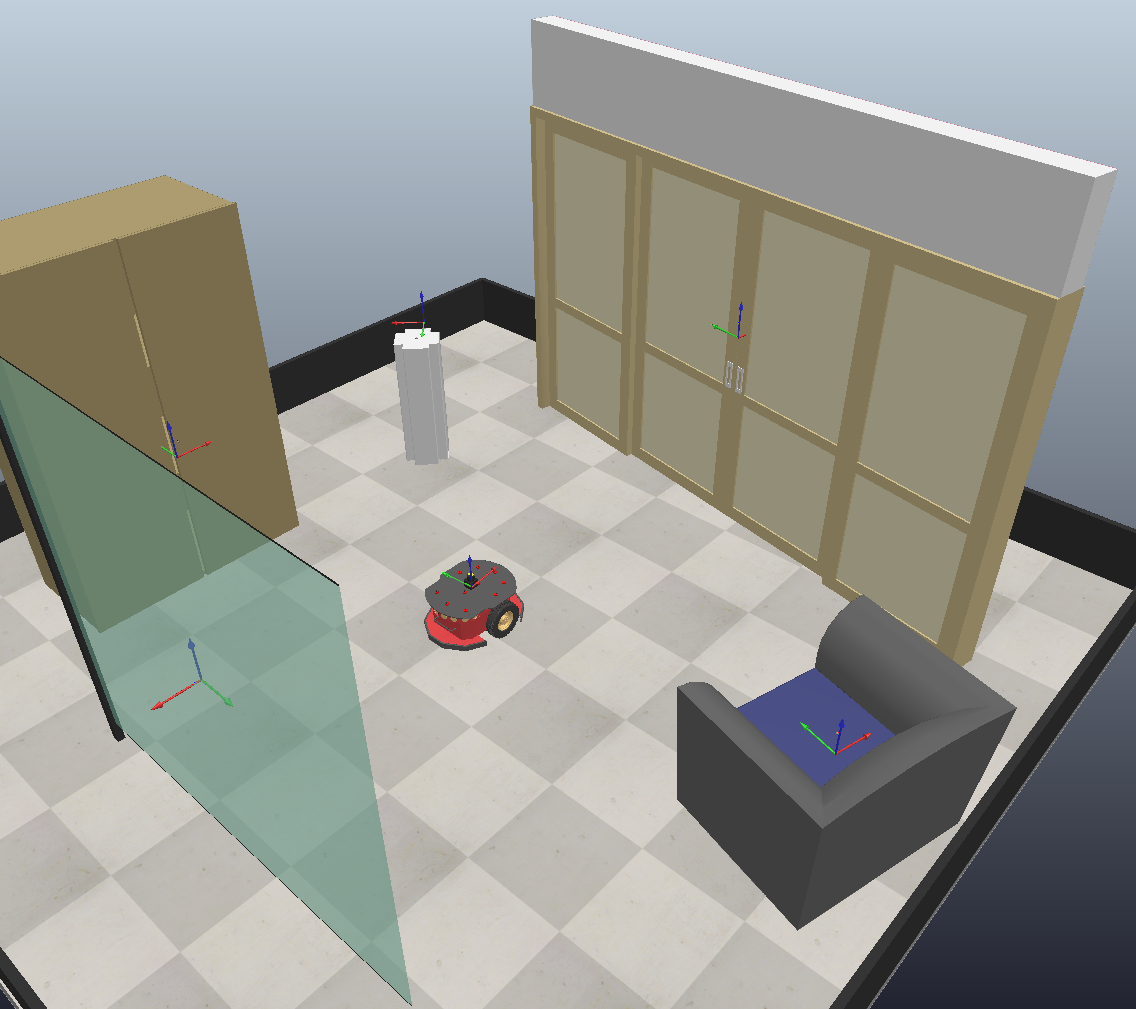

#### Q2: Define their reference frames and show the tfs between them in a diagram

- This is saved as an image: plots/q2.png

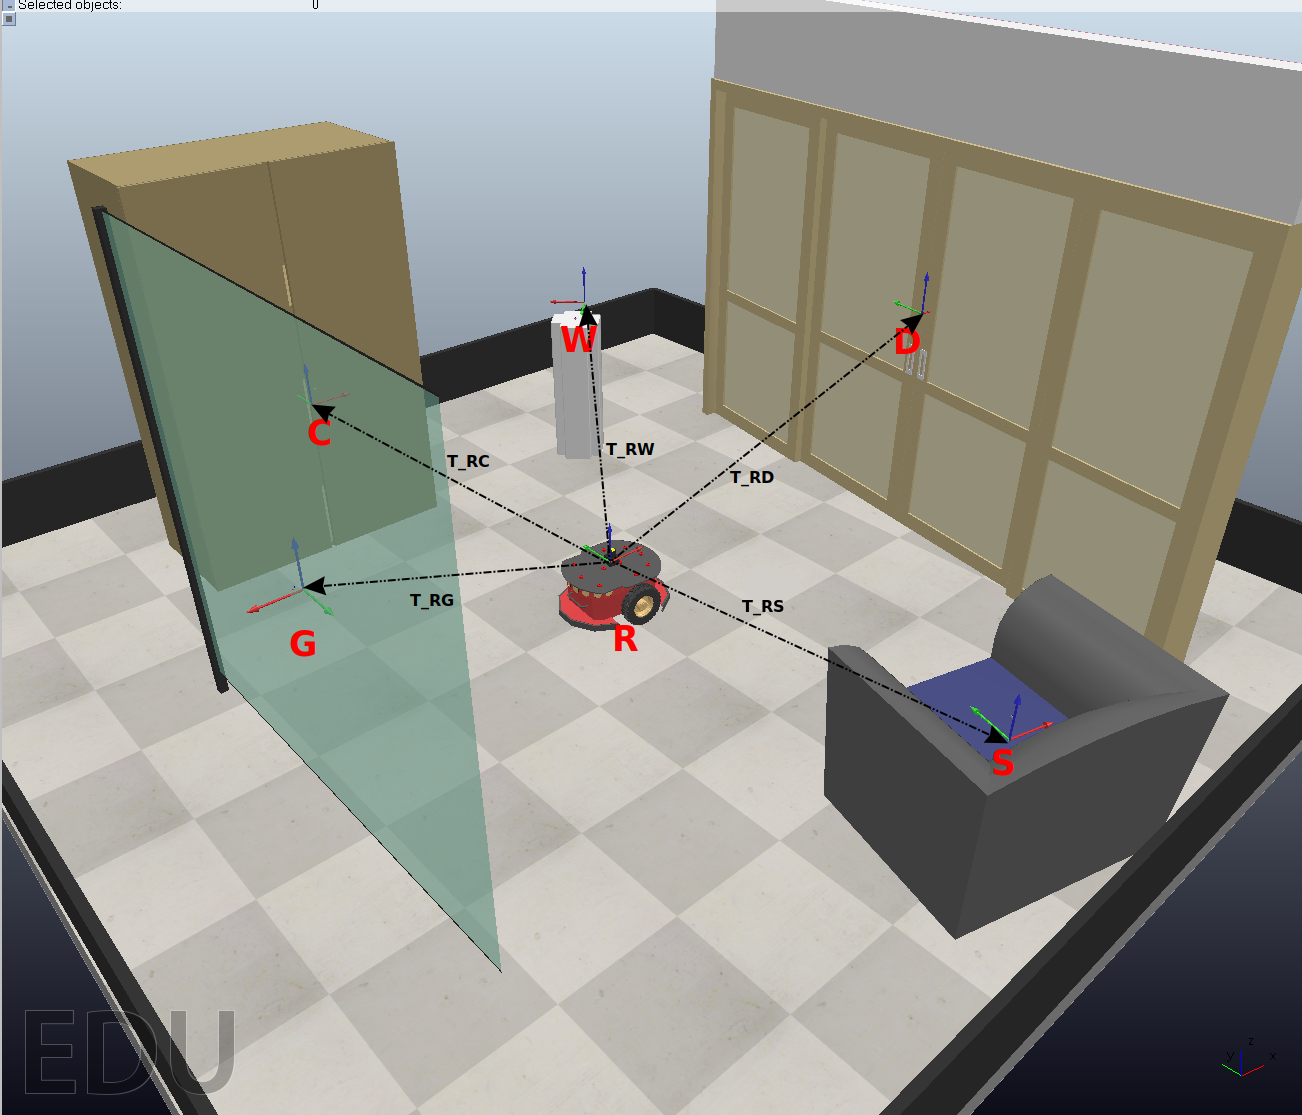

#### Q3: Plot the transforms from the robot to all objects in the scene

########################################
Executing exercise 3
########################################
Transform from robot to glass_frame: 
[[ 0.99 -0.14  0.    0.68]
 [ 0.14  0.99 -0.    0.56]
 [-0.    0.    1.    0.86]
 [ 0.    0.    0.    1.  ]]
----------------------------------------
Transform from robot to sofa_frame: 
[[-0.99 -0.12  0.   -1.25]
 [ 0.12 -0.99 -0.    1.91]
 [ 0.    0.    1.    0.36]
 [ 0.    0.    0.    1.  ]]
----------------------------------------
Transform from robot to door_frame: 
[[-1.   -0.04  0.   -2.52]
 [ 0.04 -1.   -0.    0.14]
 [ 0.    0.    1.    1.07]
 [ 0.    0.    0.    1.  ]]
----------------------------------------
Transform from robot to wall_x_frame: 
[[ 0.8   0.6   0.   -1.59]
 [-0.6   0.8  -0.   -1.5 ]
 [-0.   -0.    1.    0.67]
 [ 0.    0.    0.    1.  ]]
----------------------------------------
Transform from robot to closet_frame: 
[[-0.99  0.14  0.    0.01]
 [-0.14 -0.99 -0.   -1.15]
 [ 0.   -0.    1.    0.76]
 [ 0.    0.    0.    1.  ]

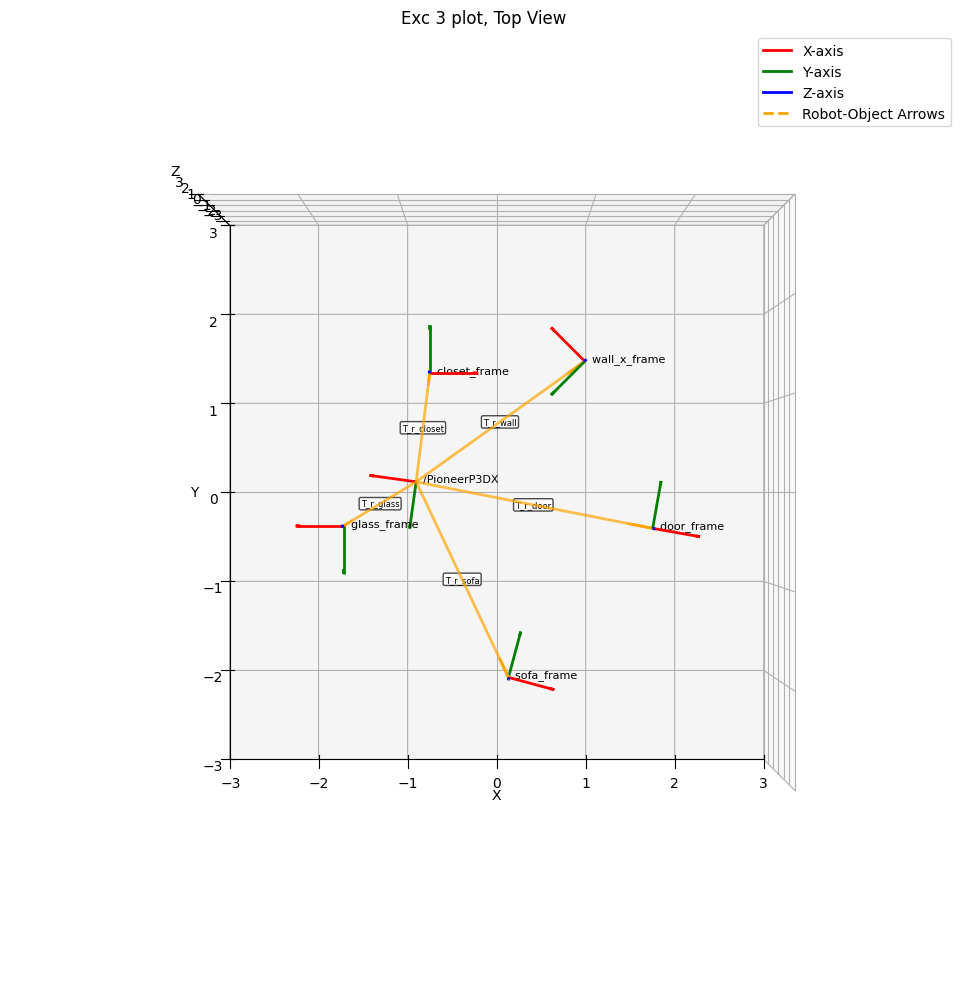

In [7]:
tp1.exc(3)

#### Question 4 - Repeat question 3 for 3x other random poses

########################################
Executing exercise 4
########################################
Generated random pose 1: 
[[-0.45 -0.89  0.    0.78]
 [ 0.89 -0.45  0.   -0.  ]
 [ 0.    0.    1.    0.14]
 [ 0.    0.    0.    1.  ]]
Transform from robot to glass_frame: 
[[ 0.45 -0.89 -0.    0.77]
 [ 0.89  0.45 -0.    2.28]
 [ 0.    0.    1.    0.86]
 [ 0.    0.    0.    1.  ]]
----------------------------------------
Transform from robot to sofa_frame: 
[[-0.67  0.74  0.   -1.44]
 [-0.74 -0.67  0.    1.47]
 [ 0.    0.    1.    0.36]
 [ 0.    0.    0.    1.  ]]
----------------------------------------
Transform from robot to door_frame: 
[[-0.6   0.8   0.   -0.72]
 [-0.8  -0.6   0.   -0.58]
 [ 0.    0.    1.    1.06]
 [ 0.    0.    0.    1.  ]]
----------------------------------------
Transform from robot to wall_x_frame: 
[[ 0.95 -0.31 -0.    1.16]
 [ 0.31  0.95 -0.   -0.75]
 [ 0.    0.    1.    0.66]
 [ 0.    0.    0.    1.  ]]
----------------------------------------
Transform f

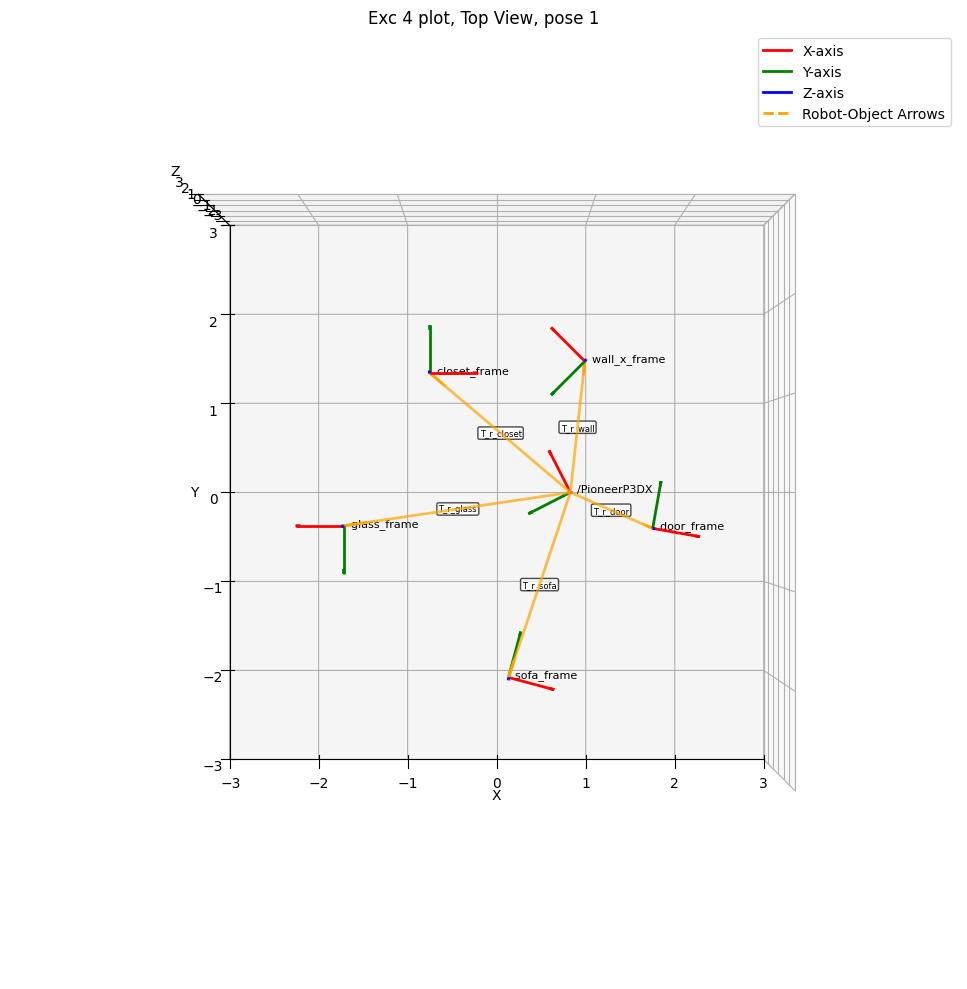

3D frame plot saved as 'plots/q4_perspective_plot_1.png'


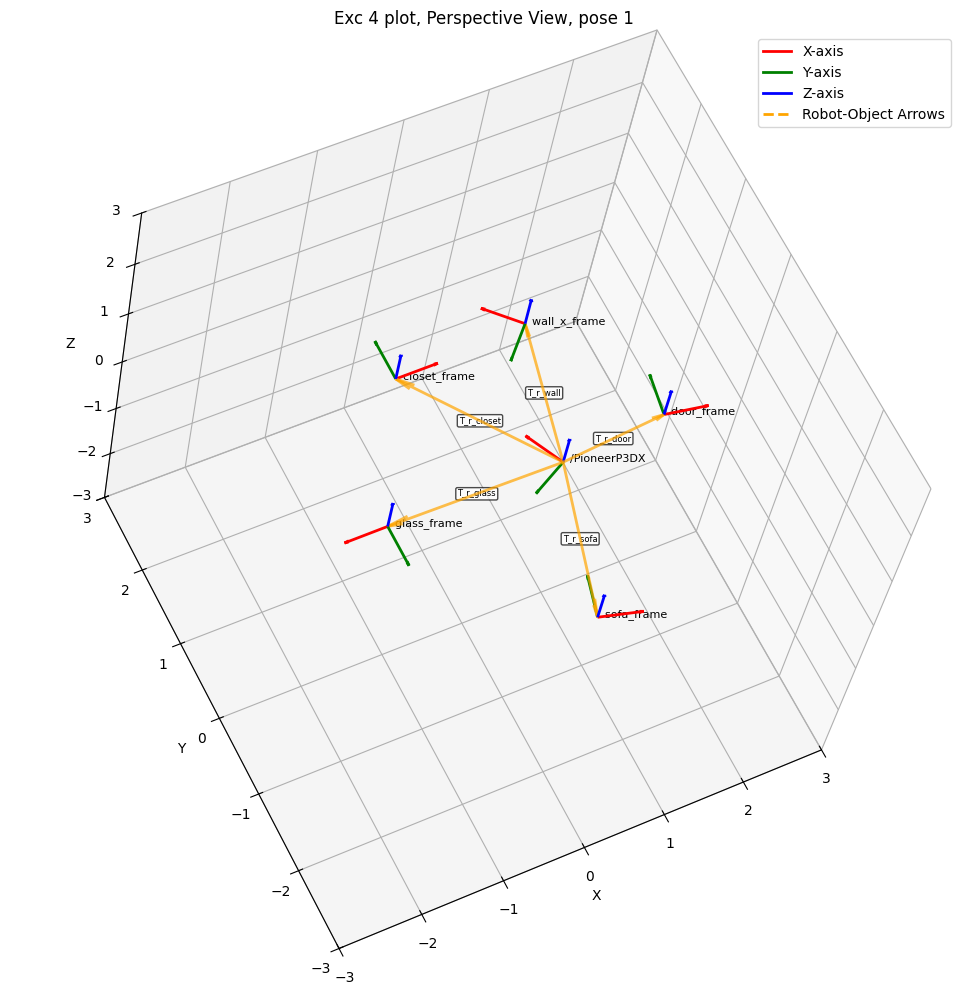

Generated random pose 2: 
[[ 0.97  0.24  0.    0.05]
 [-0.24  0.97  0.    0.21]
 [ 0.    0.    1.    0.14]
 [ 0.    0.    0.    1.  ]]
Transform from robot to glass_frame: 
[[-0.97  0.24  0.   -1.47]
 [-0.24 -0.97  0.   -0.94]
 [ 0.    0.    1.    0.86]
 [ 0.    0.    0.    1.  ]]
----------------------------------------
Transform from robot to sofa_frame: 
[[ 1.    0.02 -0.    0.59]
 [-0.02  1.    0.   -2.08]
 [ 0.    0.    1.    0.36]
 [ 0.    0.    0.    1.  ]]
----------------------------------------
Transform from robot to door_frame: 
[[ 1.   -0.07 -0.    1.66]
 [ 0.07  1.   -0.   -0.19]
 [ 0.    0.    1.    1.06]
 [ 0.    0.    0.    1.  ]]
----------------------------------------
Transform from robot to wall_x_frame: 
[[-0.86 -0.51  0.    0.56]
 [ 0.51 -0.86 -0.    1.34]
 [ 0.    0.    1.    0.66]
 [ 0.    0.    0.    1.  ]]
----------------------------------------
Transform from robot to closet_frame: 
[[ 0.97 -0.24 -0.   -0.98]
 [ 0.24  0.97 -0.    0.83]
 [ 0.    0.    1.    

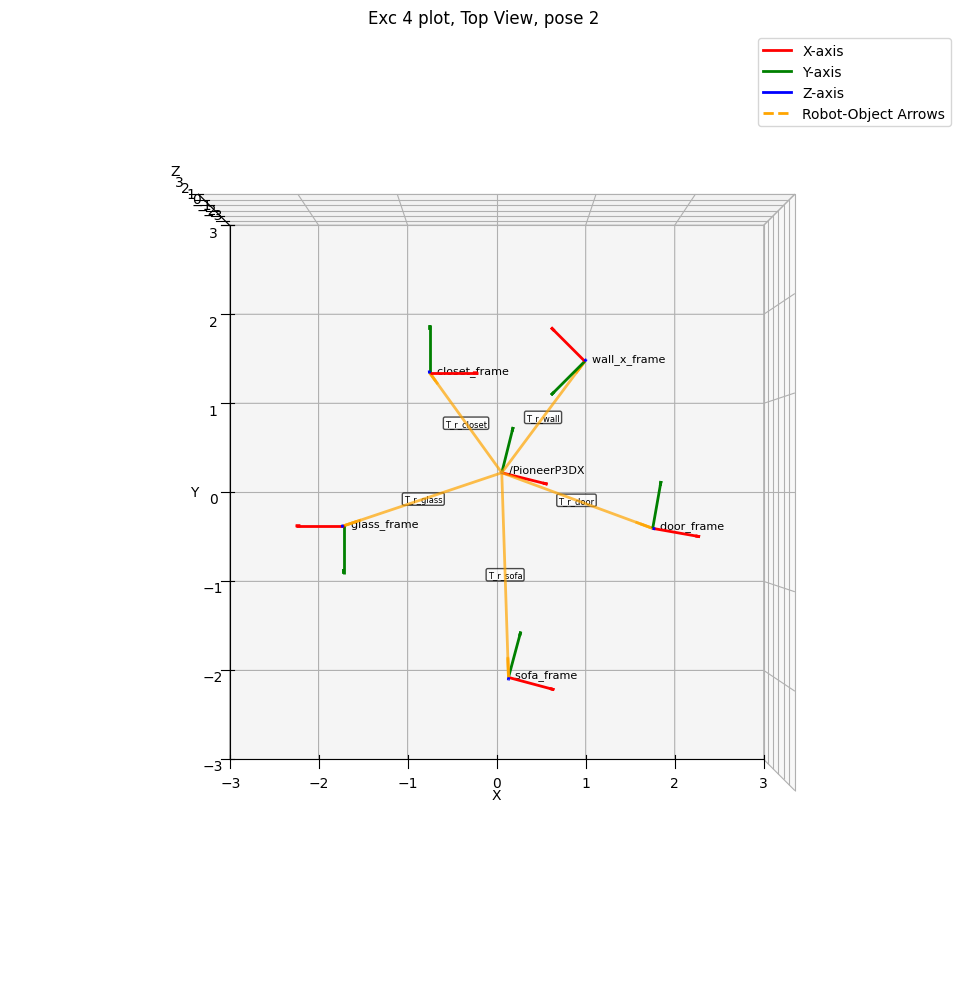

3D frame plot saved as 'plots/q4_perspective_plot_2.png'


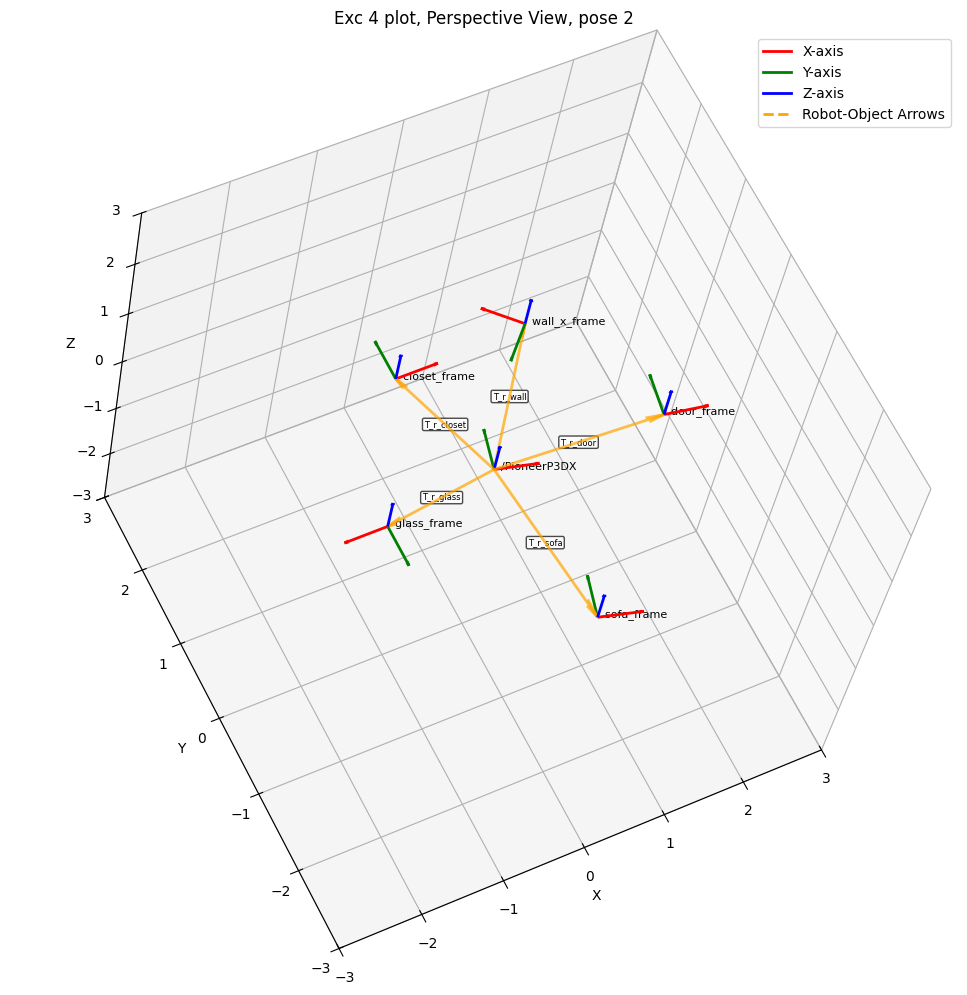

Generated random pose 3: 
[[-0.99 -0.14  0.   -0.85]
 [ 0.14 -0.99  0.    0.11]
 [ 0.    0.    1.    0.14]
 [ 0.    0.    0.    1.  ]]
Transform from robot to glass_frame: 
[[ 0.99 -0.14 -0.    0.68]
 [ 0.14  0.99 -0.    0.56]
 [ 0.    0.    1.    0.86]
 [ 0.    0.    0.    1.  ]]
----------------------------------------
Transform from robot to sofa_frame: 
[[-0.99 -0.12  0.   -1.25]
 [ 0.12 -0.99 -0.    1.91]
 [ 0.    0.    1.    0.36]
 [ 0.    0.    0.    1.  ]]
----------------------------------------
Transform from robot to door_frame: 
[[-1.   -0.04  0.   -2.52]
 [ 0.04 -1.   -0.    0.14]
 [ 0.    0.    1.    1.06]
 [ 0.    0.    0.    1.  ]]
----------------------------------------
Transform from robot to wall_x_frame: 
[[ 0.8   0.6  -0.   -1.59]
 [-0.6   0.8   0.   -1.5 ]
 [ 0.    0.    1.    0.66]
 [ 0.    0.    0.    1.  ]]
----------------------------------------
Transform from robot to closet_frame: 
[[-0.99  0.14  0.    0.01]
 [-0.14 -0.99  0.   -1.15]
 [ 0.    0.    1.    

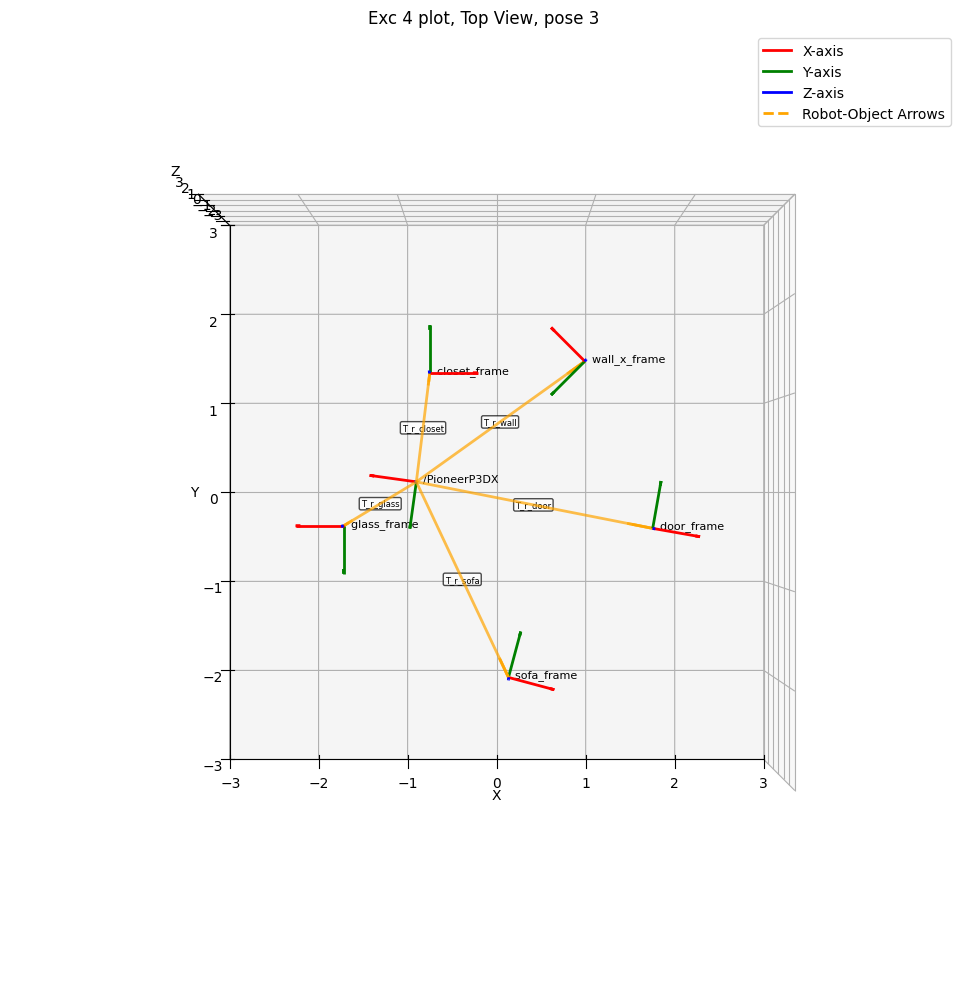

3D frame plot saved as 'plots/q4_perspective_plot_3.png'


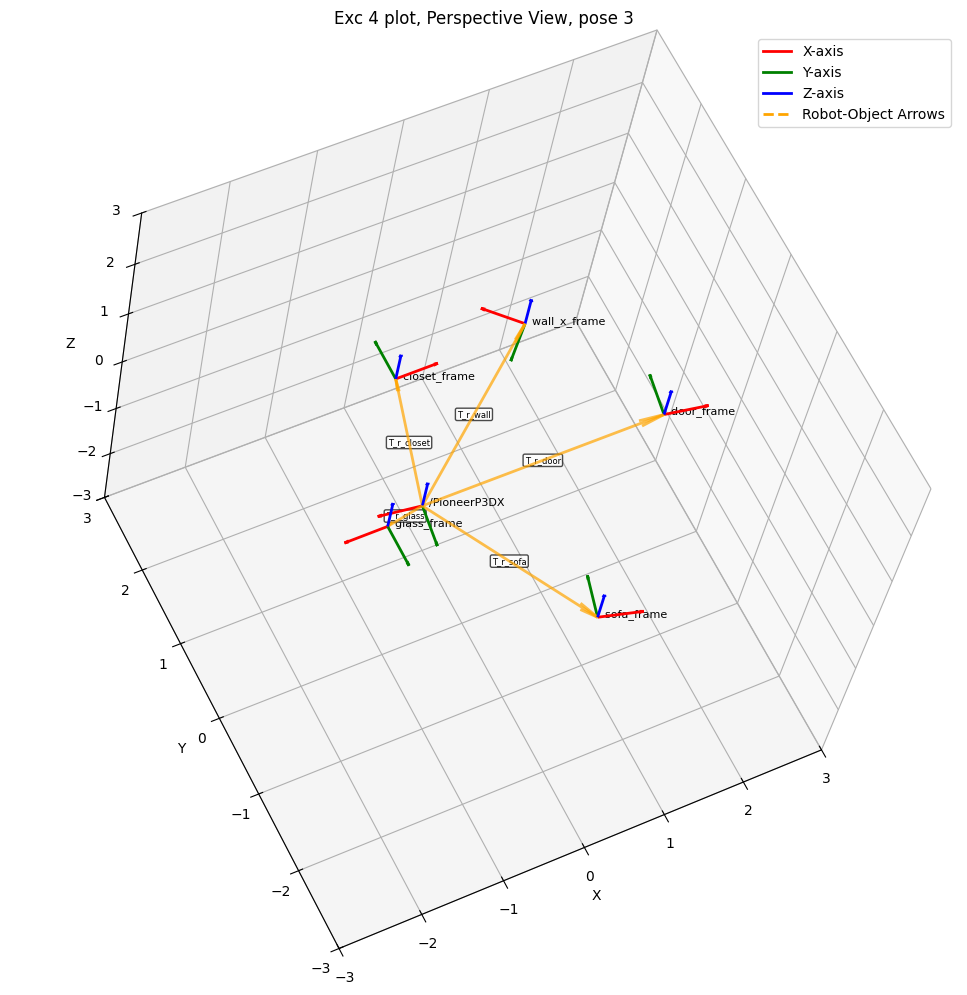

All plots generated. Plot windows should remain open.


In [8]:
tp1.exc(4)

##### Question 5
- Add a laser to the robot;
- Define transform T_r_l (robot as reference, laser being described)
- Define transform T_w_r (world as reference, robot being described)
- Plot the laser points with respect to the world frame
- p_w = T_w_l @ p_l


########################################
Executing exercise 5
########################################
Plotting robot path with 3 points
Plotting sensor data with shape: (4, 684)
Plotted 684 sensor points
Sensor data plot saved as 'plots/q5_plot_1.png'


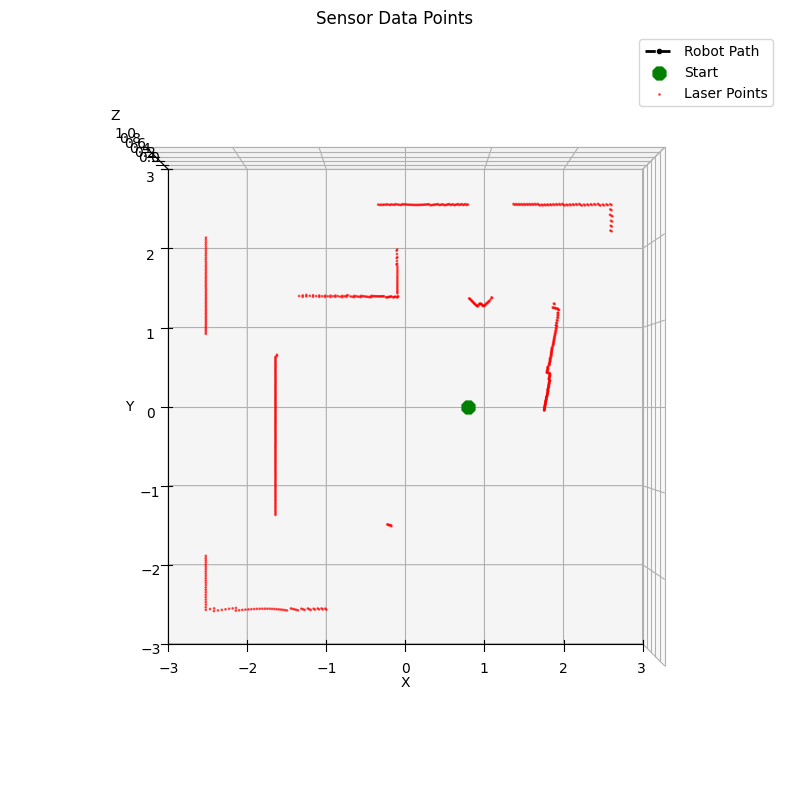

Sensor data plot displayed
Plotting robot path with 3 points
Plotting sensor data with shape: (4, 684)
Plotted 684 sensor points
Sensor data plot saved as 'plots/q5_plot_2.png'


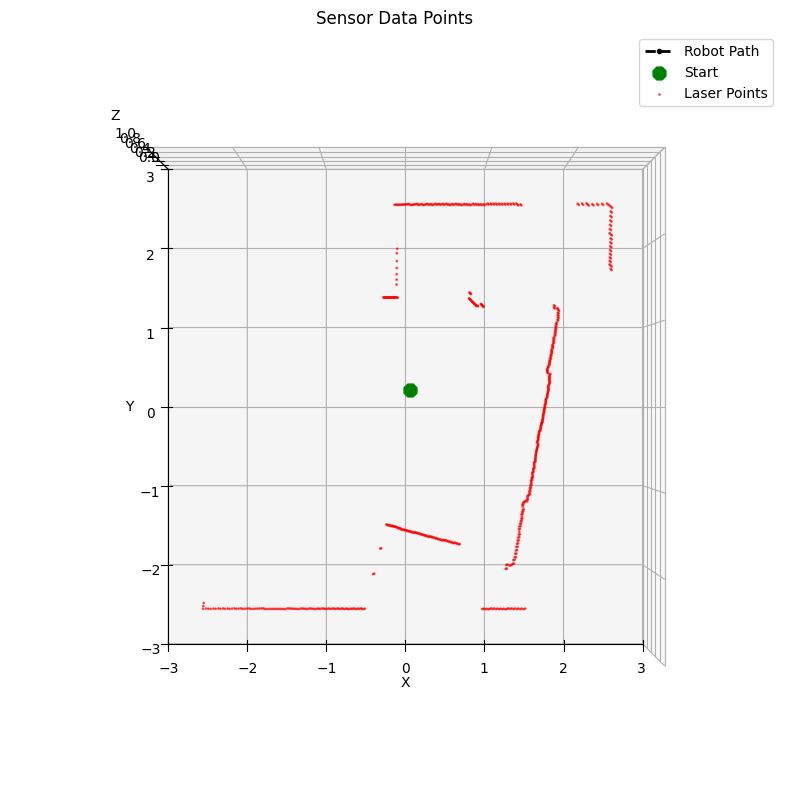

Sensor data plot displayed
Plotting robot path with 3 points
Plotting sensor data with shape: (4, 684)
Plotted 684 sensor points
Sensor data plot saved as 'plots/q5_plot_3.png'


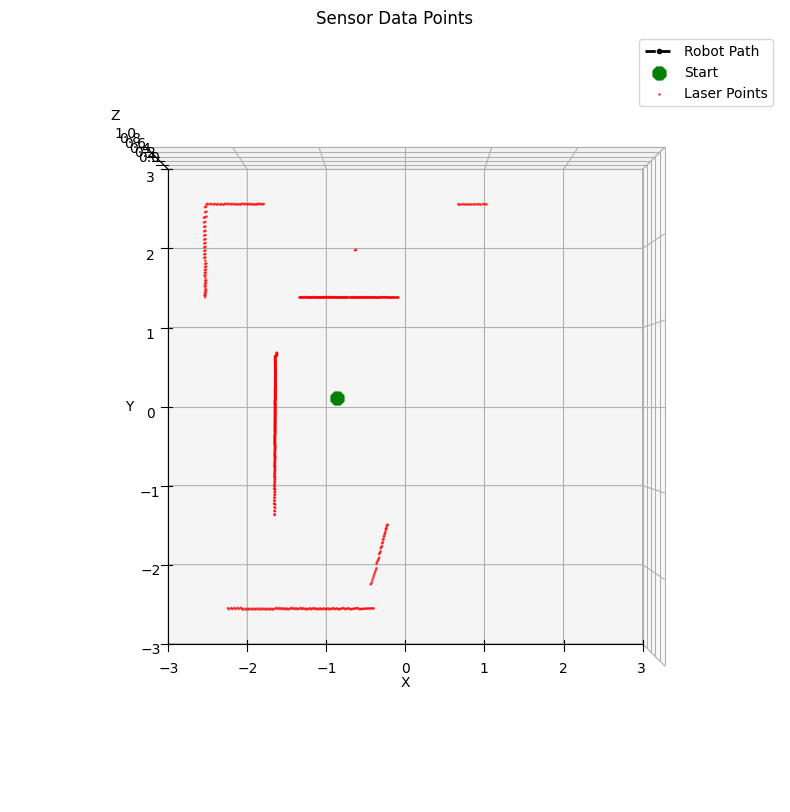

Sensor data plot displayed


In [9]:
tp1.exc(5)

#### Question 6
Make an incremental plot showing the path executed by the robot
(like a dashed line), and all the combined laser readings along
the way. They should be plotted in the world frame.


########################################
Executing exercise 6
########################################
Robot initial pose:
 [1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.1386721040330405]
Robot initial pose reshaped:
 [[1.   0.   0.   0.  ]
 [0.   1.   0.   0.  ]
 [0.   0.   1.   0.14]]
Robot initial pose reshaped and stacked:
 [[1.   0.   0.   0.  ]
 [0.   1.   0.   0.  ]
 [0.   0.   1.   0.14]
 [0.   0.   0.   1.  ]]
Resetting robot pose to
 [[1.   0.   0.   0.  ]
 [0.   1.   0.   0.  ]
 [0.   0.   1.   0.14]
 [0.   0.   0.   1.  ]]
Robot current pose:
 [[ 1.   -0.   -0.    0.  ]
 [ 0.    1.    0.   -0.  ]
 [ 0.   -0.    1.    0.14]
 [ 0.    0.    0.    1.  ]]
Getting sensor data every 3 seconds
Getting /fastHokuyo sensor data at timestep 1.
Getting /fastHokuyo sensor data at timestep 2.
Getting /fastHokuyo sensor data at timestep 3.
Getting /fastHokuyo sensor data at timestep 4.
Getting /fastHokuyo sensor data at timestep 5.
Getting /fastHokuyo sensor data at timestep 6.

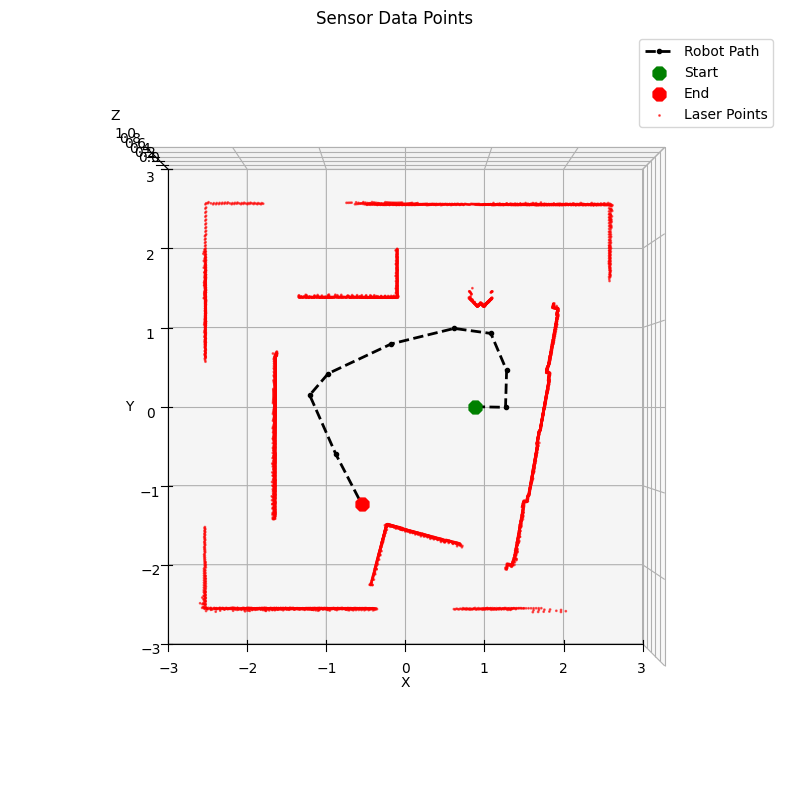

Sensor data plot displayed


<Figure size 640x480 with 0 Axes>

In [10]:
tp1.exc(6)

In [11]:
# Stop simulation and show plots
tp1.sim.stopSimulation()
plt.show(block=True)  # blocks until you manually close all windows

# Conclusion

- This assignment was a good exercise to make sure the HTM and transforms
between frames are a solidified concept
- It was also a good exercise to get used to the CoppeliaSim and its RemoteAPI
- Having to deal with different transforms and poses provided by the API was
a bit annoying, since we usually deal with 4x4 HTM, and some functions return
a 3x4 matrix (without the last row), and others return a 7-float list with
(x, y, z, qw, qx, qy, qz)
- The most challanging thing was to make sure the last plot was 100% correct.
If one doesn't use the stepping function inside sim, the last plot is almost
certainly NOT going to work, and I'll explain why:
  - If the sim keeps running indefinitely, as soon as we try to get the sensor data,
it usually takes some time `T`, which is usually much higher than the simulation
`dt`. 
  - That makes it so the robot keeps moving even during the process of data
collection from the Hokuyo sensor. 
  - Often times, when I didn't know about that, the last plot was completely
  wrong, but that's because not all points where collected while the robot was
  in the same place.
  - Some points were being collected as the robot was moving, so the transform
  for each point was different. Since the same transform was being used by all
  points, there was a `drift` in the final plot.
  - This was fixed by enabling sim stepping. The sim was then stopped just
  before collecting points, and then the data collection could be done correctly.
  - After the data collection is done, the another `step()` was done in sim.